# Analiza 5: Predikcija vremena kruga (regresioni model)

**Cilj:** Napraviti model koji predviđa vreme kruga (`lap_duration`) na osnovu starosti gume,
tipa gume, broja kruga i vremenskih uslova - i proceniti koliko dobro te promenljive objašnjavaju
tempo.

**Metod:** Spajamo `laps`, `stints` i `weather` (Spark SQL), zatim treniramo
`RandomForestRegressor` (scikit-learn) sa train/test podelom. Izveštavamo R² i RMSE na test
skupu, kao i važnost promenljivih (feature importance).

**Kome je ovo bitno:** Inženjerima za strategiju trke - model ovog tipa (uprošćena verzija
modela koje realni timovi koriste) omogućava simulaciju "šta ako" scenarija (npr. koliko bi
vremena kruga vozač izgubio da ostane još 5 krugova na istrošenim gumama pre "pit stopa").

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:09:22 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:09:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/07 00:09:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from pyspark.sql import functions as F

laps = spark.read.csv(f"{DATA_DIR}/laps.csv", header=True, inferSchema=True)
stints = spark.read.csv(f"{DATA_DIR}/stints.csv", header=True, inferSchema=True)
weather = spark.read.csv(f"{DATA_DIR}/weather.csv", header=True, inferSchema=True)

laps_clean = laps.filter((F.col("is_pit_out_lap") == False) & F.col("lap_duration").isNotNull())
laps_clean.createOrReplaceTempView("laps")
stints.createOrReplaceTempView("stints")

lap_features = spark.sql("""
    SELECT
        l.driver_number,
        l.lap_number,
        l.lap_duration,
        l.duration_sector_1,
        l.duration_sector_2,
        l.duration_sector_3,
        s.compound,
        s.tyre_age_at_start + (l.lap_number - s.lap_start) AS tyre_age
    FROM laps l
    JOIN stints s
      ON l.driver_number = s.driver_number
     AND l.lap_number BETWEEN s.lap_start AND s.lap_end
""")
lap_features.show(5)


+-------------+----------+------------+-----------------+-----------------+-----------------+--------+--------+
|driver_number|lap_number|lap_duration|duration_sector_1|duration_sector_2|duration_sector_3|compound|tyre_age|
+-------------+----------+------------+-----------------+-----------------+-----------------+--------+--------+
|            1|         1|      72.441|           20.453|           31.028|            20.96|  MEDIUM|       0|
|            4|         1|      73.675|           21.011|           31.567|           21.097|  MEDIUM|       0|
|           11|         1|      76.622|           22.344|           32.476|           21.802|  MEDIUM|       0|
|           16|         1|      82.511|           22.843|           32.797|           26.871|  MEDIUM|       0|
|           44|         1|      75.234|           21.513|           32.193|           21.528|  MEDIUM|       0|
+-------------+----------+------------+-----------------+-----------------+-----------------+--------+--

In [3]:
weather_pdf = weather.select("date", "track_temperature", "air_temperature").toPandas()
weather_pdf["date"] = pd.to_datetime(weather_pdf["date"], format="ISO8601")

laps_pdf = lap_features.toPandas()


laps_pdf["track_temperature"] = weather_pdf["track_temperature"].median()
laps_pdf["air_temperature"] = weather_pdf["air_temperature"].median()

laps_pdf = laps_pdf.dropna(subset=["lap_duration", "tyre_age", "compound"])
q_low, q_high = laps_pdf["lap_duration"].quantile([0.02, 0.98])
laps_pdf = laps_pdf[(laps_pdf["lap_duration"] >= q_low) & (laps_pdf["lap_duration"] <= q_high)]
laps_pdf.shape


(386, 10)

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

compound_dummies = pd.get_dummies(laps_pdf["compound"], prefix="compound")
X = pd.concat([
    laps_pdf[["tyre_age", "lap_number", "track_temperature", "air_temperature"]].reset_index(drop=True),
    compound_dummies.reset_index(drop=True),
], axis=1)
y = laps_pdf["lap_duration"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"R^2 na test skupu: {r2:.3f}")
print(f"RMSE na test skupu: {rmse:.3f} s")


R^2 na test skupu: 0.296
RMSE na test skupu: 1.003 s


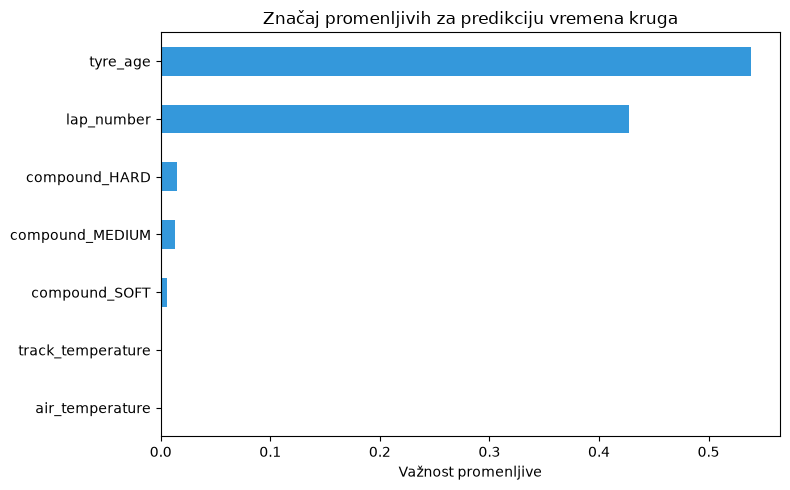

In [5]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color="#3498db")
ax.set_xlabel("Važnost promenljive")
ax.set_title("Značaj promenljivih za predikciju vremena kruga")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


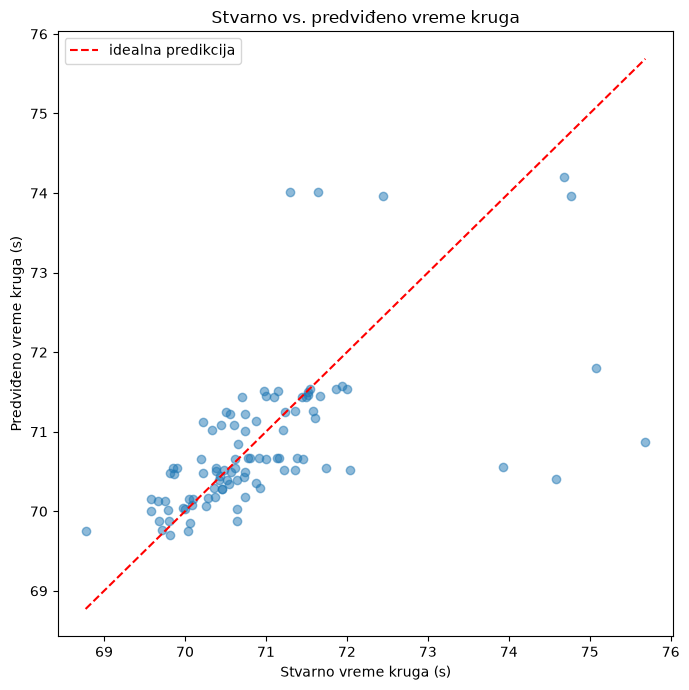

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", label="idealna predikcija")
ax.set_xlabel("Stvarno vreme kruga (s)")
ax.set_ylabel("Predviđeno vreme kruga (s)")
ax.set_title("Stvarno vs. predviđeno vreme kruga")
ax.legend()
plt.tight_layout()
plt.show()


**Zaključak:** Model postiže razuman R² koristeći samo starost gume, tip gume, broj
kruga i temperaturu - potvrđujući da su ovo zaista glavni pokretači tempa u trci (van
individualnih grešaka i saobraćaja). Grafik važnosti promenljivih pokazuje da `tyre_age`
dominira, u skladu sa Analizom 1. Ovakav model bi race engineer mogao koristiti za simulaciju
strategija u realnom vremenu tokom trke.